# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2, transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
from scipy.sparse import hstack, csr_matrix
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [ ]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cuda


## 1.3 Configuration

In [ ]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label"
RAW_DATA_FILE = "data/drugscom_plus_ai_labels.csv"
OUTPUT_DIR = "outputs_text_meta"

TEXT_COLUMN0 = "review"
TEXT_COLUMN  = "model_text"
LABEL_COLUMN = "aspect_3class"
LABEL_COLUMN_ENCODED = "sentiment_Encoded"

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Source  : {RAW_DATA_PATH}")
print(f"  Output  : {OUTPUT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

--- Configuration Loaded ---
  Project : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label
  Source  : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/data/drugscom_plus_ai_labels.csv
  Output  : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_meta
  Classes : ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
  FP16    : True


## 1.4 Load the data

In [ ]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Mounted at /content/drive/
Loaded 102061 rows.


,drugName,ingredient_norm,ingredient_set_key,n_ingredients,condition,condition_norm,review,text_norm,rating,date,...,ai_p_very_positive,ai_efficacy,ai_safety,ai_burden,ai_cost,ai_model,ai_seed,ai_temp,ai_ts_utc,ai_raw_json
uniqueID,,,,,,,,,,,,,,,,,,,,,
124923,Allopurinol,allopurinol,allopurinol,1,Gout,gout,"""\r\n300 mg and colcris to reduce anything the...",""" 300 mg and colcris to reduce anything the mi...",3,18-Feb-17,...,0.0,POSITIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612186+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
127676,Phentermine,phentermine,phentermine,1,Weight Loss,weight loss,"""\r\nA previous poster Ryan Smith said &quot;I...",""" a previous poster ryan smith said ""i've seen...",10,16-Apr-17,...,0.5,POSITIVE,NEUTRAL,POSITIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612311+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
81819,Liraglutide,liraglutide,liraglutide,1,Obesity,obesity,""" began with the minimum 0.6 mg dose of Saxend...",""" began with the minimum 0.6 mg dose of saxend...",10,18-Mar-17,...,0.1,POSITIVE,NEGATIVE,NEUTRAL,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612391+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
170223,Quetiapine,quetiapine,quetiapine,1,Bipolar Disorde,bipolar disorde,""" Caused depression and negative, self defeati...",""" caused depression and negative, self defeati...",1,25-Aug-16,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612469+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
48454,Ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,2,Birth Control,birth control,""" Ever since I started taking this birth contr...",""" ever since i started taking this birth contr...",1,30-Oct-17,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612538+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."


In [ ]:
# -- R1 label-granularity baseline: primary 5-class collapsed to 3-class ----
ASPECT_COLS = ["ai_efficacy", "ai_safety", "ai_burden", "ai_cost"]

WEIGHT_SCHEME_NAME = "integer_2112_primary_3class_collapsed"
WEIGHT_SCHEME_NOTE = "Reviewer baseline: keep the primary R0 2:1:1:2 aspect weights and submitted thresholds, then collapse the 5-class fused label to 3 classes."
THRESHOLD_SCHEME_NAME = "primary_2112_submitted"
THRESHOLD_SCHEME_NOTE = "Submitted thresholds: score >= 5 very positive, >= 2 positive, >= -1 neutral, >= -4 negative, else very negative."
LABEL_GRANULARITY_NAME = "collapsed_5class_to_3class"

# Keep the submitted integer 2:1:1:2 weighting and primary thresholds.
ASPECT_WEIGHTS_RAW = {
    "ai_efficacy": 2.0,
    "ai_safety": 1.0,
    "ai_burden": 1.0,
    "ai_cost": 2.0
}
POLARITY_MAP = {"POSITIVE": 1, "NEUTRAL": 0, "NEGATIVE": -1}
TARGET_SCORE_RANGE = 6.0
WEIGHT_SCALE = TARGET_SCORE_RANGE / sum(abs(v) for v in ASPECT_WEIGHTS_RAW.values())
ASPECT_WEIGHTS = {k: float(v) * WEIGHT_SCALE for k, v in ASPECT_WEIGHTS_RAW.items()}

print(f"=== R1 label granularity baseline: {LABEL_GRANULARITY_NAME} ===")
print(WEIGHT_SCHEME_NOTE)
print(THRESHOLD_SCHEME_NOTE)
print("Raw weights:", ASPECT_WEIGHTS_RAW)
print("Scaled weights (sum abs = 6):", {k: round(v, 4) for k, v in ASPECT_WEIGHTS.items()})

# -- 1. Per-record counts (unweighted, for reference) -----
for val in ["POSITIVE", "NEGATIVE", "NEUTRAL"]:
    df_raw[f"n_{val.lower()}"] = (
        df_raw[ASPECT_COLS].apply(lambda row: (row == val).sum(), axis=1)
    )

# -- 2. Weighted score normalized to R0 score range [-6, +6] --
df_raw["aspect_wscore"] = sum(
    ASPECT_WEIGHTS[asp] * df_raw[asp].map(POLARITY_MAP).fillna(0).astype(float)
    for asp in ASPECT_COLS
)

df_raw["aspect_weight_scheme"] = WEIGHT_SCHEME_NAME
df_raw["aspect_threshold_scheme"] = THRESHOLD_SCHEME_NAME
df_raw["aspect_label_granularity"] = LABEL_GRANULARITY_NAME

print("=== Weighted aspect score distribution ===")
print(df_raw["aspect_wscore"].round(4).value_counts().sort_index())

print("=== Cross-tab: aspect counts ===")
print(f"Mean #POSITIVE per record: {df_raw['n_positive'].mean():.2f}")
print(f"Mean #NEGATIVE per record: {df_raw['n_negative'].mean():.2f}")
print(f"Mean #NEUTRAL  per record: {df_raw['n_neutral'].mean():.2f}")

# -- 3. Derive primary hard 5-class label from weighted score -----
def wscore_to_5class(score):
    if score >= 5:
        return "VERY_POSITIVE"
    elif score >= 2:
        return "POSITIVE"
    elif score >= -1:
        return "NEUTRAL"
    elif score >= -4:
        return "NEGATIVE"
    else:
        return "VERY_NEGATIVE"

COLLAPSE_5_TO_3 = {
    "VERY_NEGATIVE": "NEGATIVE",
    "NEGATIVE": "NEGATIVE",
    "NEUTRAL": "NEUTRAL",
    "POSITIVE": "POSITIVE",
    "VERY_POSITIVE": "POSITIVE",
}

df_raw["aspect_5class"] = df_raw["aspect_wscore"].apply(wscore_to_5class)
df_raw["aspect_3class"] = df_raw["aspect_5class"].map(COLLAPSE_5_TO_3)

print("=== Primary aspect-derived 5-class distribution ===")
print(df_raw["aspect_5class"].value_counts())
print("=== Collapsed aspect-derived 3-class distribution ===")
print(df_raw["aspect_3class"].value_counts())


=== R1 label granularity baseline: collapsed_5class_to_3class ===
Reviewer baseline: keep the primary R0 2:1:1:2 aspect weights and submitted thresholds, then collapse the 5-class fused label to 3 classes.
Submitted thresholds: score >= 5 very positive, >= 2 positive, >= -1 neutral, >= -4 negative, else very negative.
Raw weights: {'ai_efficacy': 2.0, 'ai_safety': 1.0, 'ai_burden': 1.0, 'ai_cost': 2.0}
Scaled weights (sum abs = 6): {'ai_efficacy': 2.0, 'ai_safety': 1.0, 'ai_burden': 1.0, 'ai_cost': 2.0}
=== Weighted aspect score distribution ===
aspect_wscore
-6.0     1272
-5.0      547
-4.0    18286
-3.0     6209
-2.0     4507
-1.0     3551
 0.0     8450
 1.0    11396
 2.0    19364
 3.0    17120
 4.0     9354
 5.0      907
 6.0     1098
Name: count, dtype: int64
=== Cross-tab: aspect counts ===
Mean #POSITIVE per record: 1.07
Mean #NEGATIVE per record: 1.07
Mean #NEUTRAL  per record: 1.85
=== Primary aspect-derived 5-class distribution ===
aspect_5class
POSITIVE         45838
NEGATIVE

# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [ ]:
df_raw["ingredient_set_key"] = (df_raw["ingredient_set_key"].fillna("")
                                .astype(str).str.lower().str.strip()
                                .str.replace(r"\s+", " ", regex=True))
df_raw["condition_norm"] = (df_raw["condition_norm"].fillna("")
                            .astype(str).str.lower().str.strip()
                            .str.replace(r"\s+", " ", regex=True))
df_raw["n_ingredients"] = pd.to_numeric(df_raw["n_ingredients"], errors="coerce").fillna(0).astype(int)

# Keep needed columns
df_raw = df_raw.reset_index()
df_raw = df_raw[[TEXT_COLUMN0, LABEL_COLUMN, "aspect_5class", "n_ingredients", "ingredient_set_key", "condition_norm", 'n_positive', 'n_negative', 'n_neutral', 'aspect_wscore', 'aspect_weight_scheme', 'aspect_threshold_scheme', 'aspect_label_granularity']]

In [ ]:
def build_model_text(r):
    return (f"[COND] {r['condition_norm']} "
            f"[ING] {r['ingredient_set_key']} "
            f"[N_ING] {r['n_ingredients']} "
            f"[TEXT] {r[TEXT_COLUMN0]}")

df_raw[TEXT_COLUMN] = df_raw.apply(build_model_text, axis=1)

print(f"\n{LABEL_COLUMN} distribution:")
print(df_raw[LABEL_COLUMN].value_counts())


aspect_3class distribution:
aspect_3class
POSITIVE    47843
NEGATIVE    30821
NEUTRAL     23397
Name: count, dtype: int64


In [ ]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,review,aspect_3class,aspect_5class,n_ingredients,ingredient_set_key,condition_norm,n_positive,n_negative,n_neutral,aspect_wscore,aspect_weight_scheme,aspect_threshold_scheme,aspect_label_granularity,model_text
0,"""I was never one to have severe acne, just a f...",POSITIVE,POSITIVE,2,benzoyl peroxide / clindamycin,acne,3,0,1,4.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] acne [ING] benzoyl peroxide / clindamyc...
1,"""I&#039;ve had the Nexplanon since May 2015.I ...",NEUTRAL,NEUTRAL,1,etonogestrel,birth control,1,1,2,1.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] birth control [ING] etonogestrel [N_ING...
2,"""I have been taking Buspar for just over 8 mon...",POSITIVE,POSITIVE,1,buspirone,anxiety,2,0,2,3.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] anxiety [ING] buspirone [N_ING] 1 [TEXT...
3,"""I&#039;ve been on this for two weeks. I went ...",POSITIVE,POSITIVE,1,buspirone,anxiety,2,0,2,3.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] anxiety [ING] buspirone [N_ING] 1 [TEXT...
4,"""I Love this medication!!! My blood sugar stay...",NEUTRAL,NEUTRAL,1,liraglutide,"diabetes, type 2",1,2,1,-1.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,"[COND] diabetes, type 2 [ING] liraglutide [N_I..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102056,"""My lover and I had unprotected sex on 12/26 w...",POSITIVE,POSITIVE,1,levonorgestrel,emergency contraception,1,0,3,2.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] emergency contraception [ING] levonorge...
102057,"""Great for relief of back pain BUT severe side...",NEGATIVE,NEGATIVE,2,esomeprazole / naproxen,osteoarthritis,0,3,1,-4.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] osteoarthritis [ING] esomeprazole / nap...
102058,"""I am a 30 year old female who has had eczema ...",POSITIVE,POSITIVE,1,dupilumab,eczema,1,0,3,2.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] eczema [ING] dupilumab [N_ING] 1 [TEXT]...
102059,"""Used for 4.6years. Experienced many common s...",NEUTRAL,NEUTRAL,1,letrozole,breast cance,0,0,4,0.0,integer_2112_primary_3class_collapsed,primary_2112_submitted,collapsed_5class_to_3class,[COND] breast cance [ING] letrozole [N_ING] 1 ...


## 2.2 Master Data Preparation

In [ ]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [ ]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")

Label mapping: {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df_clean: 102061 rows


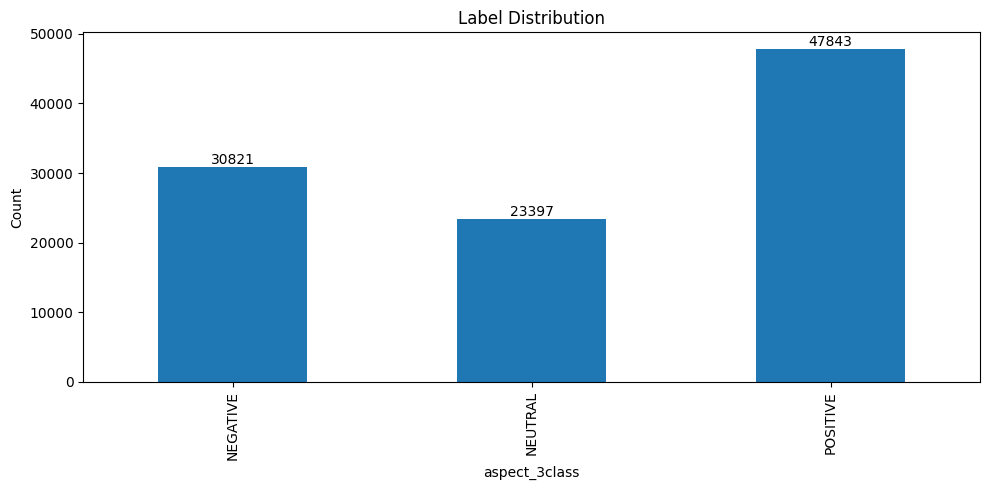

In [ ]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "DrugReview_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    61237
test     20412
val      20412
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.600004
test     0.199998
val      0.199998
Name: proportion, dtype: float64
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_meta/DrugReview_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [ ]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [ ]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [ ]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)


train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=61237, val=20412, test=20412
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([61237, 200]), val=torch.Size([20412, 200]), test=torch.Size([20412, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ALBERT tokens: train=torch.Size([61237, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=0.7776 | Val F1=0.7639
  Epoch 2/9 | Loss=0.5321 | Val F1=0.7707
  Epoch 3/9 | Loss=0.4303 | Val F1=0.7954
  Epoch 4/9 | Loss=0.3255 | Val F1=0.8020
  Epoch 5/9 | Loss=0.2096 | Val F1=0.7959
  Epoch 6/9 | Loss=0.1122 | Val F1=0.7952
  Epoch 7/9 | Loss=0.0499 | Val F1=0.7958
  Early stopping at epoch 7.


ALBERT Random Search: 100%|██████████| 10/10 [1:26:32<00:00, 519.26s/it]


ALBERT tuning: 5192.6s | Best F1=0.8020
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 160/160 [00:11<00:00, 13.44it/s]



Evaluation: ALBERT
              precision    recall  f1-score   support

    NEGATIVE     0.8992    0.8133    0.8541      6154
     NEUTRAL     0.5666    0.6613    0.6103      4636
    POSITIVE     0.8673    0.8504    0.8588      9622

    accuracy                         0.7963     20412
   macro avg     0.7777    0.7750    0.7744     20412
weighted avg     0.8086    0.7963    0.8009     20412

Weighted F1: 0.8010  95% CI [0.7954, 0.8063]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_meta/ALBERT_confusion_matrix.png


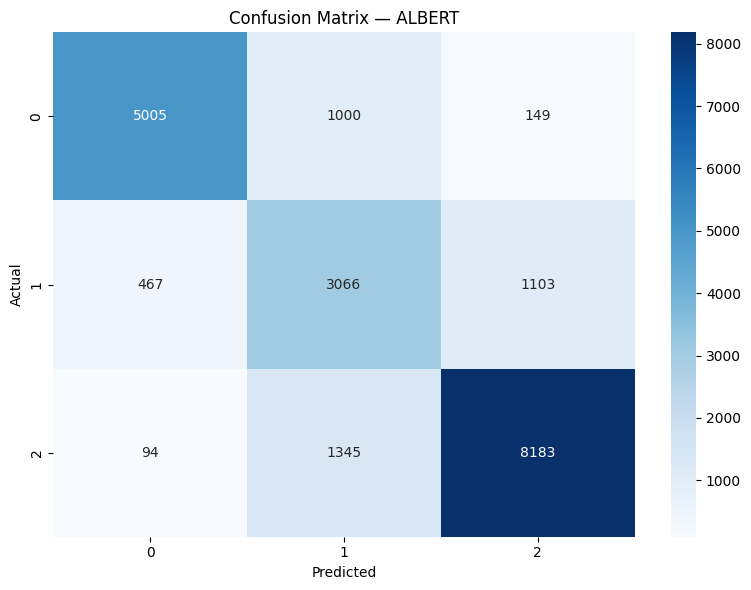

Macro AUC: 0.9270  95% CI [0.9242, 0.9298]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_meta/ALBERT_roc_curve.png


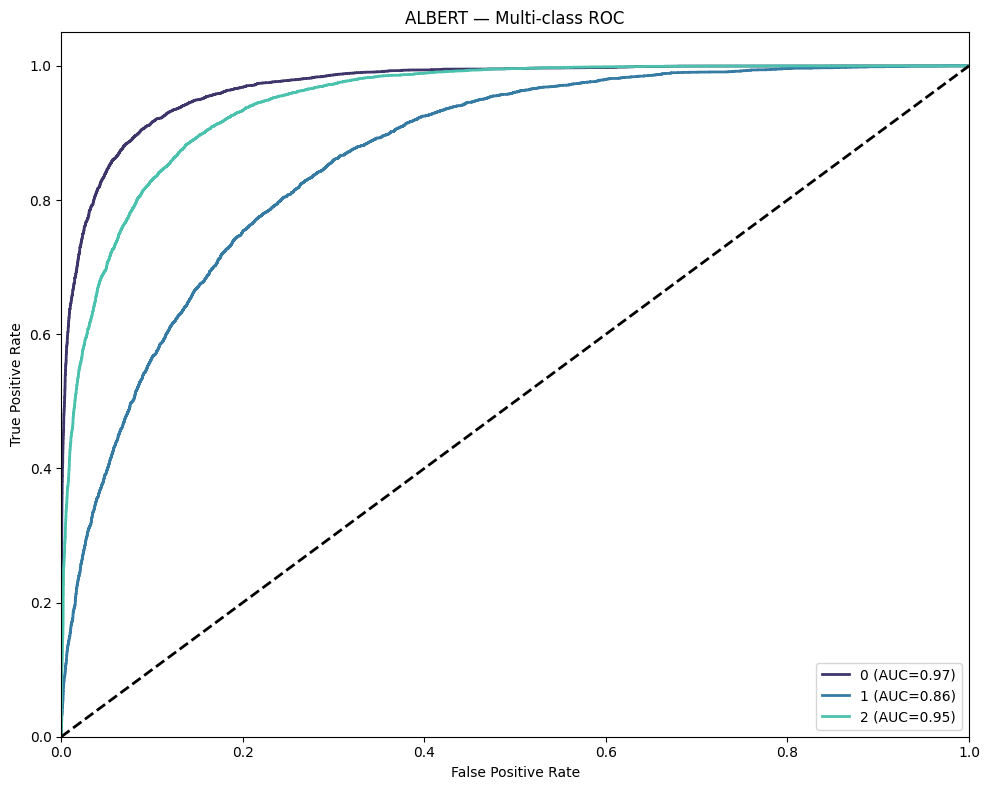

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-base-cased-v1.2"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioBERT tokens: train=torch.Size([61237, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        model.config.hidden_dropout_prob = hp["dropout"]
        model.config.attention_probs_dropout_prob = hp["dropout"]

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
else:
    print("Loading BioBERT from disk...")
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, num_labels=NUM_CLASSES,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")


Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

  Epoch 1/9 | Loss=0.8298 | Val F1=0.7566
  Epoch 2/9 | Loss=0.5521 | Val F1=0.7685
  Epoch 3/9 | Loss=0.4259 | Val F1=0.7749
  Epoch 4/9 | Loss=0.3104 | Val F1=0.7849
  Epoch 5/9 | Loss=0.2187 | Val F1=0.7821
  Epoch 6/9 | Loss=0.1527 | Val F1=0.7851
  Epoch 7/9 | Loss=0.1087 | Val F1=0.7871
  Epoch 8/9 | Loss=0.0793 | Val F1=0.7878
  Epoch 9/9 | Loss=0.0680 | Val F1=0.7869


BioBERT Random Search: 100%|██████████| 10/10 [1:03:56<00:00, 383.68s/it]


BioBERT tuning: 3836.8s | Best F1=0.7880
Best params: {'lr': 1.3271033162649868e-05, 'epochs': 9, 'dropout': 0.195692122900145}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 160/160 [00:04<00:00, 33.78it/s]



Evaluation: BioBERT
              precision    recall  f1-score   support

    NEGATIVE     0.8743    0.8047    0.8380      6154
     NEUTRAL     0.5560    0.6398    0.5949      4636
    POSITIVE     0.8611    0.8424    0.8517      9622

    accuracy                         0.7850     20412
   macro avg     0.7638    0.7623    0.7616     20412
weighted avg     0.7958    0.7850    0.7893     20412

Weighted F1: 0.7893  95% CI [0.7837, 0.7947]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_meta/BioBERT_confusion_matrix.png


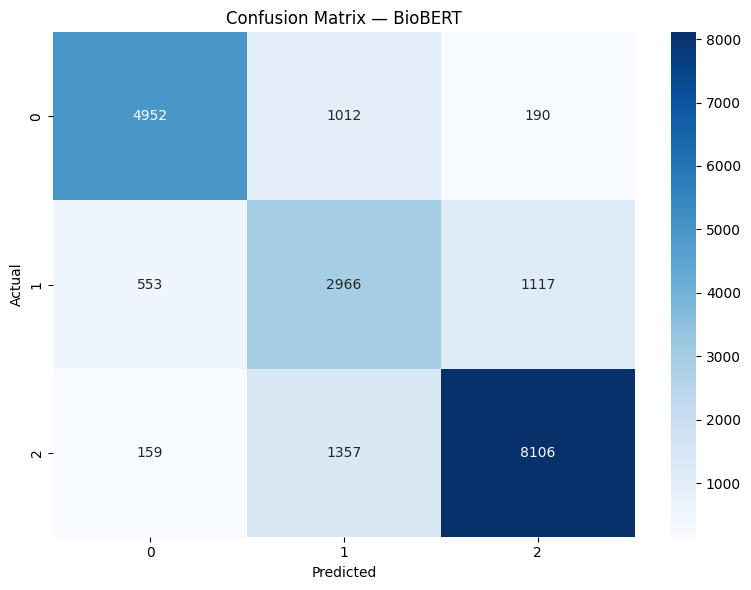

Macro AUC: 0.9193  95% CI [0.9165, 0.9221]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/05_three_class_hard_label/outputs_text_meta/BioBERT_roc_curve.png


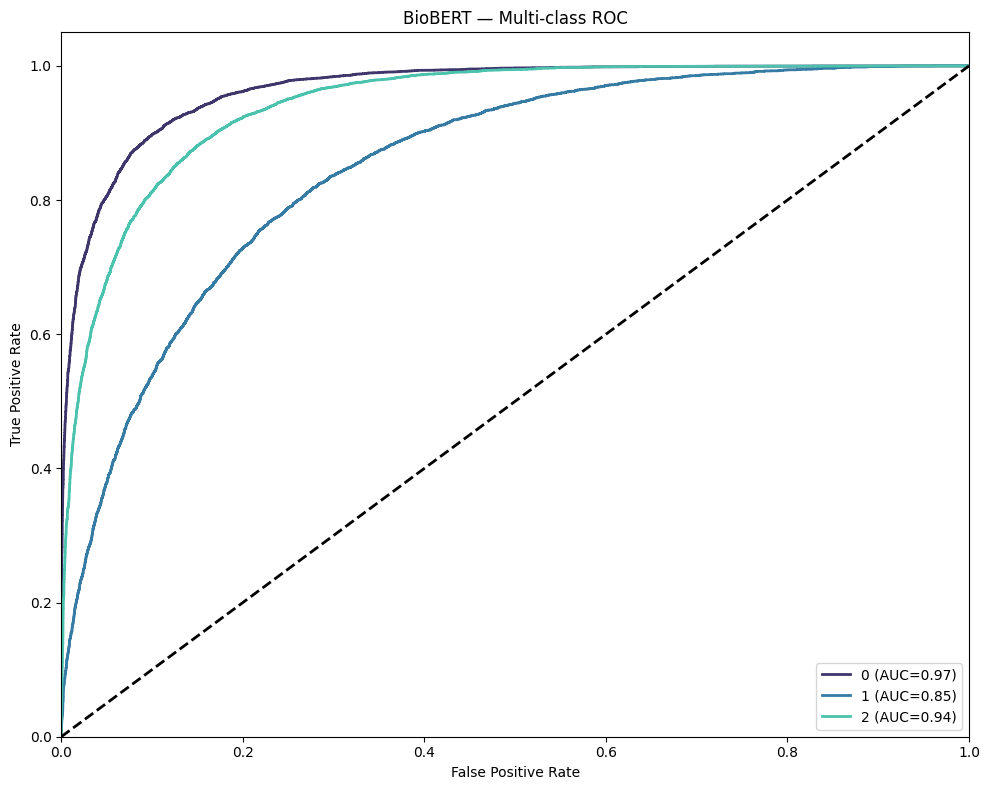

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)